# Child Poverty Risk Scoring

Child poverty in England is not evenly distributed, it clusters in specific neighbourhoods, driven by combinations of factors that aggregate statistics rarely capture. This project builds a machine learning model to predict child poverty risk across all 33,755 Lower Super Output Areas (LSOAs) in England, identify where that risk is highest, uncover hidden pockets that official deprivation rankings miss, and track where conditions are actively getting worse.
The analysis draws on four data sources: the Index of Multiple Deprivation 2025, which provides granular socioeconomic indicators across income, employment, health, housing, crime, and education domains; the Children in Low-Income Families dataset, which tracks children in relative low income annually from 2021/22 to 2024/25; and DWP administrative records on Universal Credit, Housing Benefit, and PIP claimants from 2021 to 2025.
An XGBoost model is trained to predict each LSOA's IDACI score using IMD indicators as features. To prevent geographic data leakage, the data is split by local authority using GroupShuffleSplit. SHAP values are then used to identify which factors drive predictions and by how much.

The analysis addresses four questions:

**I.** What Drives Child Poverty Risk? (SHAP Global Interpretability)  
**II.** Which LSOAs Have the Highest Predicted Child Poverty Risk?   
**III.** Which Local Authorities Contain the Highest Concentration of 'Hidden Risk' Areas?  
**IV.** Which areas show a worsening trend in child poverty risk — currently and projected — and do the key drivers identified in the model align with observed deterioration?

## 1. Setup & Data Preparation

### 1.1 Environment Setup

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import stats
from scipy.stats import skew

from sklearn.impute import SimpleImputer
from sklearn.model_selection import  GroupShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import shap
import optuna
import os
import joblib
import glob



### 1.2 Data Acquisition: IMD, DWP, & CLIF

The **IMD 2025** is the most comprehensive small-area deprivation dataset publicly available in England, covering all 33,755 LSOAs across seven deprivation domains. It includes the **IDACI**, the official measure of income deprivation affecting children at neighbourhood level, which serves as the target variable for the model.

The **Children in Low-Income Families** dataset provides annual child poverty counts at Output Area level from 2021/22 to 2024/25, aggregated to LSOA level for trend analysis. **DWP** administrative records on **Universal Credit, Housing Benefit**, and **PIP claimants** are used in Q4 to examine whether the model's key drivers align with observed deterioration on the ground.

In [2]:
# Load IMD File 7 (master: scores, ranks, deciles, population) 
master = pd.read_csv('data\IMD\All_Ranks_Scores_Deciles_Population_Denominators.csv')
master.columns = master.columns.str.strip()
print(f"master shape: {master.shape}")
print(f"master columns: {master.columns}")

<>:2: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:2: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\ashlibek\AppData\Local\Temp\ipykernel_2848\4211292503.py:2: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  master = pd.read_csv('data\IMD\All_Ranks_Scores_Deciles_Population_Denominators.csv')


master shape: (33755, 56)
master columns: Index(['LSOA code (2021)', 'LSOA name (2021)',
       'Local Authority District code (2024)',
       'Local Authority District name (2024)',
       'Index of Multiple Deprivation (IMD) Score',
       'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
       'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)',
       'Income Score (rate)', 'Income Rank (where 1 is most deprived)',
       'Income Decile (where 1 is most deprived 10% of LSOAs)',
       'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)',
       'Employment Decile (where 1 is most deprived 10% of LSOAs)',
       'Education, Skills and Training Score',
       'Education, Skills and Training Rank (where 1 is most deprived)',
       'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)',
       'Health Deprivation and Disability Score',
       'Health Deprivation and Disability Rank (wher

In [3]:
# Load IMD File 8 (underlying indicators, one sheet per domain) 
indicators = r'data\IMD\Underlying_Indicators.xlsx'
xl = pd.ExcelFile(indicators)
indicators_sheets = xl.sheet_names 
print(f"indicators sheets: {indicators_sheets}")

indicators sheets: ['Notes', 'IoD25 Income Domain', 'IoD25 Employment Domain', 'IoD25 Education Domain', 'IoD25 Health Domain', 'IoD25 Crime Domain', 'IoD25 Barriers Domain', 'IoD25 Living Env Domain']


In [4]:
indicators_sheets.remove('Notes')  # Remove the 'Notes' sheet
 
for sheet in indicators_sheets:
    df = pd.read_excel(indicators, sheet_name=sheet)
    print(f"\n--- {sheet} ---")
    print(df.columns.tolist())


--- IoD25 Income Domain ---
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Income Domain numerator', 'Income Deprivation Affecting Children Index (IDACI) numerator', 'Income Deprivation Affecting Older People Index (IDAOPI) numerator']

--- IoD25 Employment Domain ---
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Employment Domain numerator']

--- IoD25 Education Domain ---
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Adult skills and English language proficiency indicator', 'Entry to higher education indicator']

--- IoD25 Health Domain ---
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Acute morbidity indicator', 'Comparative illness and disability ratio indicator', 'Mental health indi

In [5]:
drop_cols = ['LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)']

# We're keeping 'LSOA code (2021)' as the merge key
f8_frames = []
for sheet in indicators_sheets:
    df = pd.read_excel(indicators, sheet_name=sheet)
    indicator_cols = [c for c in df.columns if c not in drop_cols]
    f8_frames.append(df[indicator_cols])

# Merge all indicator sheets on 'LSOA code (2021)'
f8 = f8_frames[0]
for frame in f8_frames[1:]:
    f8 = f8.merge(frame, on='LSOA code (2021)', how='left')

print(f8.shape)

(33755, 39)


In [70]:
# Load Child Poverty data (2021-2025)
cilif = pd.read_csv('data/lsoa_BHC - Relative Low Income.csv')

# Load Universal Credit data (2021-2025)
uc_yearly = {}

for year in [2021, 2022, 2023, 2024, 2025]:
    path = f'data/People on Universal Credit/lsoa_People on Universal Credit {year}.csv'
    df = pd.read_csv(path)
    # Drop non-data columns, keep only monthly value columns
    month_cols = [c for c in df.columns if c not in ['Month', 'LSOA21CD']]
    df[month_cols] = df[month_cols].apply(pd.to_numeric, errors='coerce')
    # Sum Output Areas within each LSOA first, then take annual mean across months
    lsoa_sum = df.groupby('LSOA21CD')[month_cols].sum(min_count=1)
    lsoa_sum['uc_mean'] = lsoa_sum.mean(axis=1)
    uc_yearly[year] = lsoa_sum[['uc_mean']].reset_index()

# Load PIP data (2021-2025)
pip_yearly = {}
for year in [2021, 2022, 2023, 2024, 2025]:
    path = f'data/PIP Cases with Entitlement/lsoa_PIP Cases with Entitlement {year}.csv'
    df = pd.read_csv(path)
    month_cols = [c for c in df.columns if c not in ['Month', 'LSOA21CD']]
    df[month_cols] = df[month_cols].apply(pd.to_numeric, errors='coerce')
    lsoa_sum = df.groupby('LSOA21CD')[month_cols].sum(min_count=1)
    lsoa_sum['pip_mean'] = lsoa_sum.mean(axis=1)
    pip_yearly[year] = lsoa_sum[['pip_mean']].reset_index()

# Load Housing Benefit data (2021-2025)
hb_yearly = {}
for year in [2021, 2022, 2023, 2024, 2025]:
    path = f'data/Housing Benefit Claimants/lsoa_Housing Benefit Claimants {year}.csv'
    df = pd.read_csv(path)
    month_cols = [c for c in df.columns if c not in ['Month', 'LSOA21CD']]
    df[month_cols] = df[month_cols].apply(pd.to_numeric, errors='coerce')
    lsoa_sum = df.groupby('LSOA21CD')[month_cols].sum(min_count=1)
    lsoa_sum['hb_mean'] = lsoa_sum.mean(axis=1)
    hb_yearly[year] = lsoa_sum[['hb_mean']].reset_index()

print(f"UC 2021 sample:\n{uc_yearly[2021].head()}")
print(f"\nPIP 2021 sample:\n{pip_yearly[2021].head()}")
print(f"\nHB 2021 sample:\n{hb_yearly[2021].head()}")

UC 2021 sample:
    LSOA21CD     uc_mean
0  E01000001   24.000000
1  E01000002   15.583333
2  E01000003   87.833333
3  E01000005  179.416667
4  E01000006  289.083333

PIP 2021 sample:
    LSOA21CD  pip_mean
0  E01000001       NaN
1  E01000002       NaN
2  E01000003     48.00
3  E01000005     60.50
4  E01000006     37.25

HB 2021 sample:
    LSOA21CD     hb_mean
0  E01000001    5.222222
1  E01000002    5.000000
2  E01000003   90.538462
3  E01000005  100.846154
4  E01000006   43.307692


In [ ]:
# Load Police Crime data (2021-2025) - Violence and sexual offences as proxy for stalking/harassment
police_yearly = {}

for (start, end), year in zip([(21,22),(22,23),(23,24),(24,25),(25,26)], [2021,2022,2023,2024,2025]):
    search_path = f'data/Police/Police {start}-{end}/**/*.csv'
    all_files = glob.glob(search_path, recursive=True)
    
    filtered_files = [
        f for f in all_files
        if 'stop' not in os.path.basename(f).lower()
        and 'outcome' not in os.path.basename(f).lower()
    ]
    
    frames = []
    for file in filtered_files:
        df = pd.read_csv(file, usecols=['LSOA code', 'Crime type'], low_memory=False)
        df = df[df['Crime type'] == 'Violence and sexual offences'][['LSOA code']].copy()
        frames.append(df)
    
    yearly = pd.concat(frames, ignore_index=True)
    police_yearly[year] = yearly.groupby('LSOA code').size().reset_index(name='violence_count')


In [76]:

# Print summary of loaded data
print(f"UC years loaded: {list(uc_yearly.keys())}")
print(f"PIP years loaded: {list(pip_yearly.keys())}")
print(f"HB years loaded: {list(hb_yearly.keys())}")
print(f"Police years loaded: {list(police_yearly.keys())}")


UC years loaded: [2021, 2022, 2023, 2024, 2025]
PIP years loaded: [2021, 2022, 2023, 2024, 2025]
HB years loaded: [2021, 2022, 2023, 2024, 2025]
Police years loaded: [2021, 2022, 2023, 2024, 2025]


### 1.3 Data Cleansing & Feature Engineering

In [8]:
# Merge master + indicators
df = master.merge(f8, on='LSOA code (2021)', how='left')
print(f"Master dataframe shape: {df.shape}")

# Quick sense check 
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTarget variable (IDACI Score) - sample stats:")
print(df['Income Deprivation Affecting Children Index (IDACI) Score (rate)'].describe())

Master dataframe shape: (33755, 94)

Missing values:
Income Domain numerator                                                 5
Income Deprivation Affecting Children Index (IDACI) numerator         815
Income Deprivation Affecting Older People Index (IDAOPI) numerator    832
Employment Domain numerator                                            21
Entry to higher education indicator                                    34
dtype: int64

Target variable (IDACI Score) - sample stats:
count    33755.000000
mean         0.341749
std          0.211003
min          0.003000
25%          0.169500
50%          0.298000
75%          0.489000
max          1.000000
Name: Income Deprivation Affecting Children Index (IDACI) Score (rate), dtype: float64


**Missing Values:**

- The IDACI numerator has 815 missing values, but the score itself is complete. The reason for this discrepancy is not explicitly documented in the IMD 2025 technical report. Since our target variable is the score, not the numerator, this does not affect the analysis.
- IDAOPI numerator has 832 missing values and measures older people in income deprivation, unrelated to child poverty risk and will be dropped from the feature set.
- Others are tiny (5–34 out of 33,755), safe to impute with median.

**Target variable looks healthy:**

- Range 0.003 to 1.0: full spread
- Mean 0.34, median 0.30: slight right skew (mean > median)
- No nulls 

**Data Quality Note:** LSOA E01034220 (Newham) contains an erroneous IDACI score of 0.979 in the source file. The official IMD 2025 value is 0.198. Corrected prior to training.

In [9]:
# Fix the one missing value in the target variable (IDACI Score) using the known value from the source dataset.
df.loc[df['LSOA code (2021)'] == 'E01034220', 
       'Income Deprivation Affecting Children Index (IDACI) Score (rate)'] = 0.198

In [10]:
# Feature Column Definition and Leakage Assessment
# Define target 
TARGET = 'Income Deprivation Affecting Children Index (IDACI) Score (rate)'

y = df[TARGET]

# Drop identifiers
id_cols = ['LSOA code (2021)', 'LSOA name (2021)',
           'Local Authority District code (2024)', 
           'Local Authority District name (2024)']

# Drop target and direct IDACI leakage
target_leakage = [c for c in df.columns if 'IDACI' in c]

# Drop IDAOPI score/rank/decile only — keep numerator
idaopi_drop = [c for c in df.columns if 'IDAOPI' in c and 'numerator' not in c]

# Drop rank/decile columns
rank_decile_cols = [c for c in df.columns if 'Rank' in c or 'Decile' in c]

# Drop domain/sub-domain/IMD scores — but keep raw deprivation scores from File 8
keep_scores = [
    'Connectivity Score',
    'Housing energy performance deprivation Score',
    'Housing lacking private outdoor space deprivation score'
]

score_cols = [c for c in df.columns if 'Score' in c 
              and c != TARGET 
              and c not in keep_scores]

# Drop income-related leakage
income_drop = ['Income Score (rate)', 
               'Income Domain numerator',
               'Income Deprivation Affecting Older People Index (IDAOPI) numerator']

# Drop housing composite
housing_composite = ['Housing affordability indicator']

all_drop = set(id_cols + target_leakage + idaopi_drop + rank_decile_cols 
               + list(score_cols) + income_drop + housing_composite)

feature_cols = [c for c in df.columns if c not in all_drop]

print(f"Features kept ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")

# CiLIF: Aggregate OA → LSOA and compute trend slopes (by summing the counts for each year, grouped by 'LSOA21CD')
year_cols = ['2021/22', '2022/23', '2023/24', '2024/25']
cilif[year_cols] = cilif[year_cols].apply(pd.to_numeric, errors='coerce')
cilif_lsoa = cilif.groupby('LSOA21CD')[year_cols].sum().reset_index()

# Add population denominator from IMD
pop = df[['LSOA code (2021)', 'Dependent Children aged 0-15: mid 2022']].copy()
pop.columns = ['LSOA21CD', 'dep_children']
cilif_lsoa = cilif_lsoa.merge(pop, on='LSOA21CD', how='left')

# Exclude LSOAs where all years are zero (no children recorded in any year)
cilif_lsoa = cilif_lsoa[cilif_lsoa[year_cols].sum(axis=1) > 0].reset_index(drop=True)

# Fit linear trend per LSOA
x = np.array([1, 2, 3, 4])

def get_slope(row):
    y_vals = row[year_cols].values.astype(float)
    return np.polyfit(x, y_vals, 1)[0]

def get_projected(row):
    y_vals = row[year_cols].values.astype(float)
    slope, intercept = np.polyfit(x, y_vals, 1)
    return round(intercept + slope * 5, 1)  # year 5 = 2025/26

cilif_lsoa['Slope'] = cilif_lsoa.apply(get_slope, axis=1)
cilif_lsoa['Proj_2026'] = cilif_lsoa.apply(get_projected, axis=1)

# A raw slope of +10 means very different things in an LSOA with 50 children vs one with 500
# Dividing by population and scaling to per 1,000 puts all LSOAs on a level playing field
# per 1,000 is the conventional choice for small-area population statistics in UK public health 
# and deprivation analysis, matching the scale used in IMD indicators and DWP reporting)
cilif_lsoa['Slope_per1000'] = (
    cilif_lsoa['Slope'] / cilif_lsoa['dep_children'] * 1000
)


Features kept (38):
  Total population: mid 2022
  Dependent Children aged 0-15: mid 2022
  Older population aged 60 and over: mid 2022
  Working age population 18-66 (for use with Employment Deprivation Domain): mid 2022
  Employment Domain numerator
  Adult skills and English language proficiency indicator
  Entry to higher education indicator
  Acute morbidity indicator
  Comparative illness and disability ratio indicator
  Mental health indicator
  Years of potential life lost indicator
  Violence with injury, rate per 1,000 'at-risk population'
  Violence without injury, rate per 1,000 'at-risk population'
  Stalking and harassment, rate per 1,000 'at-risk population'
  Burglary, rate per 1,000 'at-risk properties'
  Theft, rate per 1,000 'at-risk population'
  Criminal damage, rate per 1,000 'at-risk population'
  Public order and Possession of weapons, rate per 1,000 'at-risk population'
  Anti-Social Behaviour, rate per 1,000 'at-risk population'
  Connectivity Score
  Owner-oc

In [11]:
X = df[feature_cols].copy()

#  Impute missing values 
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)
X_imputed['Worklessness rate (derived)'] = (
    X_imputed['Employment Domain numerator'] / 
    X_imputed['Working age population 18-66 (for use with Employment Deprivation Domain): mid 2022']
)

X_imputed['Older population rate (derived)'] = (
    X_imputed['Older population aged 60 and over: mid 2022'] / 
    df['Total population: mid 2022']
)

X_imputed['Dependent children rate (derived)'] = (
    X_imputed['Dependent Children aged 0-15: mid 2022'] / 
    df['Total population: mid 2022']
)

X_imputed.rename(columns={
    'Adult skills and English language proficiency indicator': 'Adult skills deprivation indicator'
}, inplace=True)

X_imputed.drop(columns=['Employment Domain numerator',
                        'Older population aged 60 and over: mid 2022',
                        'Dependent Children aged 0-15: mid 2022',
                        'Total population: mid 2022',
                       'Working age population 18-66 (for use with Employment Deprivation Domain): mid 2022'], 
               inplace=True)

print(f"Features: {X_imputed.shape[1]}")
print(f"Any missing: {X_imputed.isnull().sum().sum()}")

Features: 36
Any missing: 0


### 1.4 Spatial Train-Test Split (GroupShuffleSplit by Local Authority)

In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
groups = df['Local Authority District code (2024)']

train_idx, test_idx = next(gss.split(X_imputed, y, groups=groups))

X_train = X_imputed.iloc[train_idx]
X_test  = X_imputed.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Confirm no LA appears in both splits
train_las = set(groups.iloc[train_idx])
test_las  = set(groups.iloc[test_idx])
print(f"LA overlap: {len(train_las & test_las)}")  # must be 0


Train: (27043, 36), Test: (6712, 36)
LA overlap: 0


## 2. Model Development & Evaluation

### 2.1 Baseline XGBoost Evaluation

Predicting IDACI scores across 33,755 LSOAs is a tabular regression problem with non-linear relationships between deprivation indicators and child poverty risk, for example, the combined effect of worklessness and housing pressure is unlikely to be captured by a linear model alone. **XGBoost** is well suited to this type of problem: it handles non-linearity and feature interactions effectively, performs consistently on tabular data, and produces predictions that can be explained at the individual area level, which is essential for the interpretability goals of this analysis.

In [13]:
# Baseline XGBoost with sensible defaults, not tuned.
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123,
    n_jobs=-1
)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

# Evaluate
y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f"\nMAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


[0]	validation_0-rmse:0.20902
[100]	validation_0-rmse:0.08333
[200]	validation_0-rmse:0.08280
[300]	validation_0-rmse:0.08281
[400]	validation_0-rmse:0.08272
[499]	validation_0-rmse:0.08284

MAE:  0.0580
RMSE: 0.0828
R²:   0.8536


The baseline model explains **85.4%** of the variation in child poverty risk across 33,755 neighbourhoods, with an average prediction error of **5.8 percentage points**. For a spatial prediction task tested across unseen local authorities, this is a **solid starting point.** The remaining **14.6% unexplained variance** may reflect inherent noise in area-level deprivation indicators, the strict geographic split used for evaluation, or factors not captured in the IMD feature set.

### 2.2 Final Scoring Model Optimization

The evaluation model established that XGBoost generalises well to unseen local authorities. We now retrain on the full dataset (all 33,755 LSOAs) to produce the most accurate possible risk score for every neighbourhood in England. **This is the model used for all subsequent analysis: identifying the key drivers in Q1, ranking the highest-risk areas in Q2, detecting hidden risk in Q3, and examining alignment with deterioration trends in Q4.**

**Hyperparameter tuning** is performed using **Optuna**, a Bayesian optimisation framework that efficiently searches the parameter space by learning from previous trials rather than testing exhaustively. We tune six parameters: number of trees, learning rate, tree depth, subsampling rates, and minimum sample weight per leaf node, over 50 trials, using the same spatial cross-validation strategy (GroupShuffleSplit by local authority) to ensure the tuning process respects geographic boundaries and does not overfit to seen areas.

In [14]:

def tune_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 123,
        'n_jobs': -1
    }
    model = XGBRegressor(**params)
    gss_cv = GroupShuffleSplit(n_splits=3, test_size=0.2, random_state=123)
    scores = cross_val_score(model, X_imputed, y, cv=gss_cv.split(X_imputed, y, groups), scoring='r2')
    return scores.mean()

if os.path.exists('optuna_study.pkl'):
    study = joblib.load('optuna_study.pkl')
    print("Loaded existing study. Best R²:", round(study.best_value, 4))
else:
    study = optuna.create_study(direction='maximize')
    study.optimize(tune_xgboost, n_trials=50, show_progress_bar=True)
    joblib.dump(study, 'optuna_study.pkl')
    print("Best params:", study.best_params)
    print("Best R²:", round(study.best_value, 4))

Loaded existing study. Best R²: 0.8628


In [15]:
xgb_full = XGBRegressor(**study.best_params)
xgb_full.fit(X_imputed, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7441035736202816
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegre

## 3. Question I: What Drives Child Poverty Risk? (SHAP Global Interpretability)

To understand the underlying socioeconomic mechanisms driving child poverty, we must look inside our trained XGBoost model. Traditional feature importance metrics can be misleading because they only tell us *if* a variable is important, not *how* or in which direction it affects the prediction. 

To solve this, we use **SHAP (SHapley Additive exPlanations) values** rooted in game theory. This approach allows us to:
* **Quantify the exact contribution** of each Index of Multiple Deprivation (IMD) indicator to an area's predicted IDACI risk score.
* **Determine the direction of impact**, isolating which community factors push families into poverty risk and which factors act as protective buffers.
* **Filter out noise** by establishing an absolute mean SHAP threshold (5e-04) to isolate only the most statistically meaningful drivers across England's 33,755 LSOAs.

The following code calculates the SHAP values and visualises them using side-by-side Bar and Beeswarm plots to reveal both overall feature rank and local impact direction.


### 3.1 Global Feature Importance via SHAP Values

In [16]:
# Compute SHAP values 
explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_imputed)

# Get mean SHAP value per feature: positive = increases prediction, negative = decreases prediction
shap_df = pd.DataFrame(shap_values, columns=X_imputed.columns)
shap_means = shap_df.mean().abs().sort_values(ascending=False)

# Before selecting a threshold method, we test whether the SHAP distribution is symmetric or skewed.
# Mean+std thresholds assume approximate symmetry; if skewness > 1, the distribution is right-skewed,
# meaning a few features dominate while most cluster near zero. In that case, percentile-based
# thresholds are more appropriate as they are robust to skew and grounded in the data's own distribution.
print(f"Skewness: {skew(shap_means):.4f}")


Skewness: 4.4699


In [17]:
# The SHAP distribution is strongly right-skewed: a few features dominate and many contribute near zero.
# Mean+std-based thresholds are sensitive to this skew and can be overly aggressive.
# Percentile-based thresholds are robust to skew and statistically grounded in the data's own distribution.
# We scan q=0.50 to q=0.75 (median to upper quartile) to find a threshold that retains
# features with above-average predictive contribution without discarding meaningful secondary drivers.
for q in [0.5, 0.6, 0.7, 0.75]:
    t = shap_means.quantile(q)
    n = (shap_means >= t).sum()
    print(f"q={q}: threshold={t:.6f}, features kept={n}")


q=0.5: threshold=0.000220, features kept=18
q=0.6: threshold=0.000329, features kept=15
q=0.7: threshold=0.000481, features kept=11
q=0.75: threshold=0.000549, features kept=9


In [19]:
# q=0.70 is selected: retains 11 features (top 30%). q=0.75 was rejected because
# features 11 and 12 (SHAP: 0.000489, 0.000474) are too close in value to feature 10
# (0.000537) to justify dropping them; there is no meaningful gap.
threshold = shap_means.quantile(0.70)

notable = shap_means[shap_means >= threshold]
notable_features = notable.index.tolist()
notable_indices = [list(X_imputed .columns).index(f) for f in notable_features]
shap_values_notable = shap_values[:, notable_indices]
X_notable  = X_imputed [notable_features]

display_names = {
    'Worklessness rate (derived)': 'Worklessness rate',
    'Adult skills deprivation indicator': 'Adult skills deprivation',
    'Comparative illness and disability ratio indicator': 'Illness & disability ratio',
    'Household overcrowding indicator (bedrooms)': 'Overcrowding (bedrooms)',
    'Older population rate (derived)': 'Older population rate',
    'Housing energy performance deprivation Score': 'Energy performance deprivation',
    'Dependent children rate (derived)': 'Dependent children rate',
    'Owner-occupation affordability (component of housing affordability indicator)': 'Owner-occupation affordability',
    'Stalking and harassment, rate per 1,000 \'at-risk population\'': 'Stalking & harassment',
    'Housing lacking private outdoor space deprivation score': 'No private outdoor space',
    'Core homelessness rate (% of households)': 'Core homelessness rate',
    'Connectivity Score': 'Connectivity',
    'Housing in poor condition indicator': 'Housing in poor condition',
    'Violence with injury, rate per 1,000 \'at-risk population\'': 'Violence with injury',
    'Mental health indicator': 'Mental health',
    'Nitrogen dioxide (component of air quality indicator)': 'Nitrogen dioxide',
    'Air quality indicator': 'Air quality',
    'Household overcrowding indicator (rooms)': 'Overcrowding (rooms)',
    'Entry to higher education indicator': 'Entry to higher education',
    'Homelessness indicator (rate per 1,000 households)': 'Homelessness rate',
    'Public order and Possession of weapons, rate per 1,000 \'at-risk population\'':'Public order & weapons offences',
    'Violence without injury, rate per 1,000 \'at-risk population\'':'Violence without injury',
    'Private rental affordability (component of housing affordability indicator)': 'Private rental affordability'
}

X_notable_display = X_notable.rename(columns=display_names)


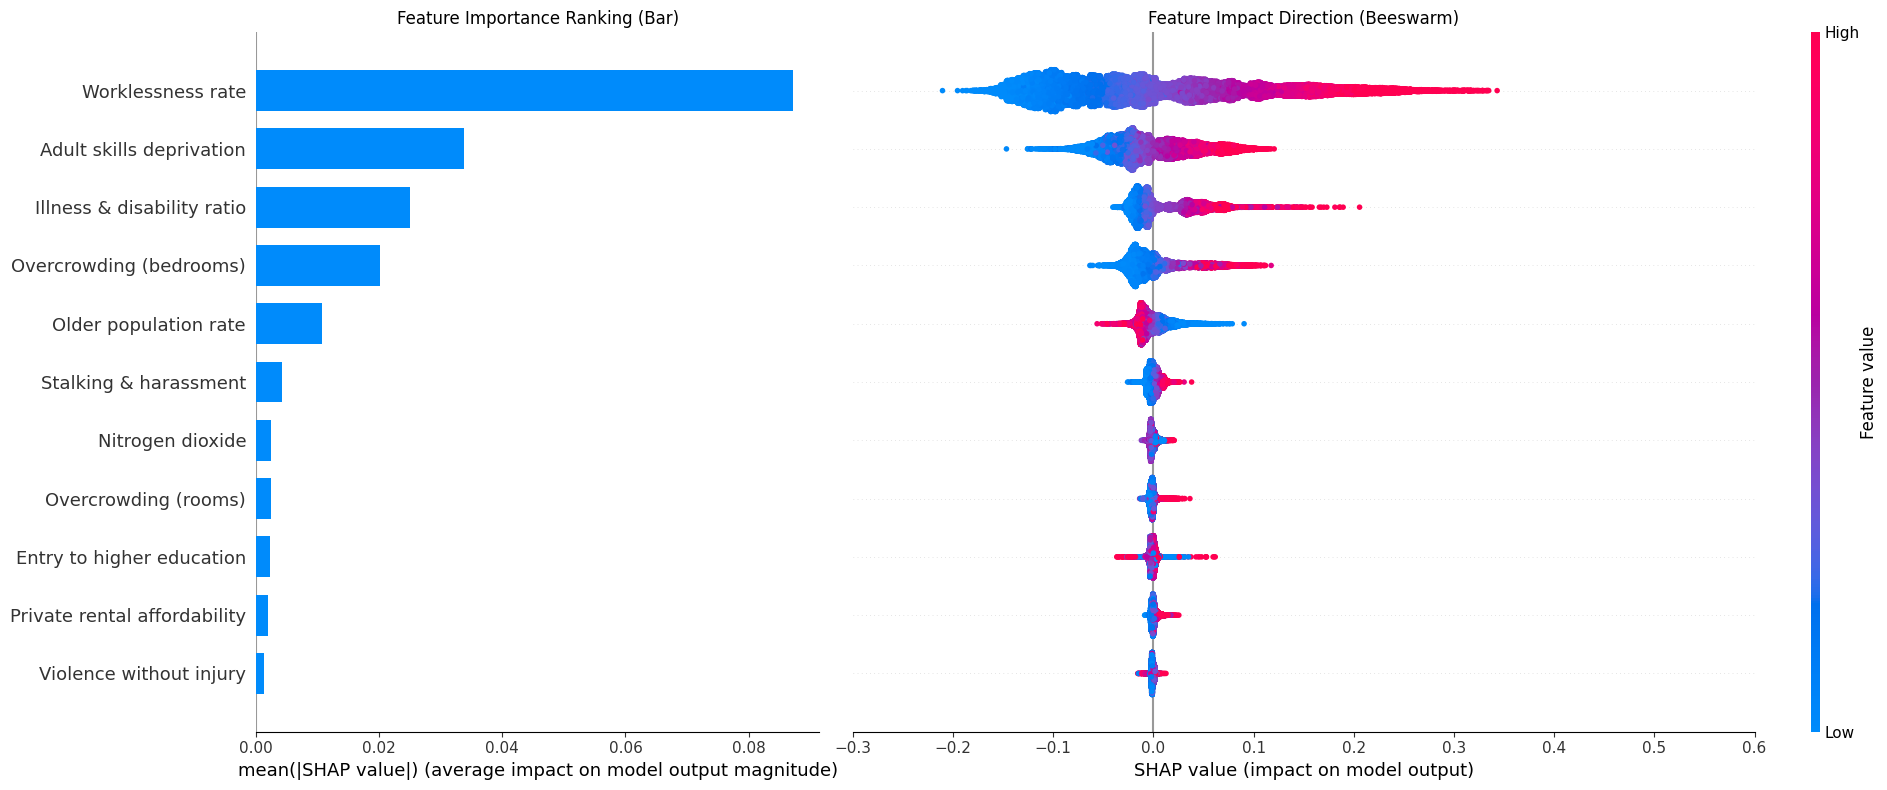

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 2]})

plt.sca(axes[0])
shap.summary_plot(shap_values_notable, X_notable_display,
                  plot_type='bar',
                  max_display=len(notable_features),
                  show=False,
                  plot_size=None)
axes[0].set_title('Feature Importance Ranking (Bar)')

plt.sca(axes[1])
shap.summary_plot(shap_values_notable, X_notable_display,
                  max_display=len(notable_features),
                  show=False,
                  plot_size=None)
axes[1].set_xlim(-0.3, 0.6)
axes[1].set_title('Feature Impact Direction (Beeswarm)')

axes[1].set_yticks([])
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('SHAP.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Primary Risk-Increasing Drivers

**Worklessness** (the state of being involuntarily out of employment among working-age adults) is the strongest predictor of child poverty risk, with an influence more than twice that of any other factor. **Low skills and qualifications** ranks second, reflecting how limited education and training constrains the types of jobs and income levels available to families in an area. **Illness and disability** comes third; poor health is closely associated with reduced household earning capacity. **Bedroom overcrowding** adds further pressure, capturing households where space constraints are correlated with broader financial hardship. **Stalking and harassment rates**, while a smaller contributor, suggest that neighbourhood safety conditions are linked to elevated poverty risk.


### 3.3 Mitigating Factors & Low-Contribution Features

**Older population rate** is the only feature that consistently reduces predicted child poverty risk, likely because such neighbourhoods tend to have fewer dependent children regardless of overall deprivation levels.

**Nitrogen dioxide, overcrowding by rooms, Entry to higher education, private rental affordability, and violence without injury** each play a small and inconsistent role. Their influence varies across neighbourhoods in both direction and magnitude, making it difficult to draw reliable conclusions about their relationship with child poverty risk at a national level.


## 4. Geospatial & Hidden Risk Identification (Model Predictions)

National deprivation statistics often flatten localized socioeconomic realities. An area can appear affluent on paper while harboring intense pockets of child poverty. This section translates our XGBoost model predictions into actionable spatial insights by shifting from country-wide feature importance to geographic specificities.

By cross-referencing our predicted IDACI risk scores with official Index of Multiple Deprivation (IMD) 2025 rankings across all 33,755 LSOAs, we aim to:
* **Pinpoint Extreme Risk Hotspots**: Locate the neighbourhoods where predicted child poverty risk is highest nationally (Question II).
* **Uncover Hidden Pockets of Disadvantage**: Identify relatively affluent Local Authorities (IMD Deciles 4–10) that mask localized, high-risk child poverty clusters (Question III).
* **Diagnose Localized Drivers**: Use SHAP waterfall plots to dissect outlier neighborhoods, revealing how unique local combinations of health, housing, and demographic pressures escape standard deprivation metrics.

This spatial analysis moves us from global modeling patterns to granular, community-level diagnostics.


### 4.1 Question II: Which LSOAs Have the Highest Predicted Child Poverty Risk?

In [21]:
# Create a clean results df
results = df[['LSOA code (2021)','Local Authority District name (2024)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)']].copy()

# Rename columns for readability
results.columns = ['LSOA_code', 'LA_name', 'IMD_Score', 'IMD_Decile']

# Add the model predictions
results['Predicted_IDACI'] = xgb_full.predict(X_imputed) # all 33,755 LSOAs

q1_ranking = results.sort_values('Predicted_IDACI', ascending=False).reset_index(drop=True)
q1_ranking.index += 1
print(q1_ranking[['LSOA_code', 'LA_name', 'IMD_Score', 'IMD_Decile', 'Predicted_IDACI']].head(20).to_string())


    LSOA_code        LA_name  IMD_Score  IMD_Decile  Predicted_IDACI
1   E01001809        Hackney     49.545           1         1.016482
2   E01001814        Hackney     50.941           1         0.998884
3   E01001725        Hackney     46.434           1         0.987683
4   E01001799        Hackney     46.542           1         0.983087
5   E01001812        Hackney     49.978           1         0.978313
6   E01001800        Hackney     61.174           1         0.973102
7   E01004702    Westminster     45.693           1         0.970740
8   E01021988       Tendring     94.223           1         0.969605
9   E01035189  Middlesbrough     71.797           1         0.968945
10  E01012670      Blackpool     88.186           1         0.966996
11  E01012040  Middlesbrough     79.882           1         0.966804
12  E01026383   West Lindsey     81.615           1         0.965836
13  E01012673      Blackpool     91.186           1         0.964555
14  E01012683      Blackpool     8

The highest predicted child poverty risk is concentrated in **Hackney** (7 LSOAs) and **Westminster** (3 LSOAs), alongside **Blackpool** (3 LSOAs), **Middlesbrough** (2 LSOAs), and individual LSOAs in **Tendring, West Lindsey, Sheffield, Rotherham, and Brent**. All top 20 LSOAs sit in **IMD decile 1**, confirming the model aligns with official deprivation rankings at the extreme end of the distribution.

### 4.2 Question III: Which Local Authorities Contain the Highest Concentration of 'Hidden Risk' Areas?

In [22]:
# Calculate dataset-specific threshold numbers using quantiles
q50 = results['Predicted_IDACI'].quantile(0.50)  # Median
q75 = results['Predicted_IDACI'].quantile(0.75)  # Top 25% 
q90 = results['Predicted_IDACI'].quantile(0.90)  # Top 10% severe risk

# First, we define a clear, fixed function to map IDACI scores to risk categories
def get_risk_tier(score):
    if score >= q90:
        return "Critical Risk"
    elif score >= q75:
        return "High Risk"
    elif score >= q50:
        return "Moderate Risk"
    else:
        return "Low Risk"   

threshold_75th = q75

hidden_risk = results[
    (results['IMD_Decile'].between(4, 10)) & 
    (results['Predicted_IDACI'] >= threshold_75th)
].sort_values(by='Predicted_IDACI', ascending=False)


la_decile = df.groupby('Local Authority District name (2024)')['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'].median().round().astype(int).reset_index()
la_decile.columns = ['LA_name', 'LA_Decile']

# Group by LA and calculate BOTH the count of LSOAs and the mean Predicted IDACI
hidden_risk_by_la = (hidden_risk.groupby('LA_name')
                     .agg(
                         Risk_Count=('Predicted_IDACI', 'size'),
                         Pred_IDACI =('Predicted_IDACI', 'mean')
                     )
                     .reset_index())

# Merge the datasets so the LA Median Deciles are included
hidden_risk_by_la = hidden_risk_by_la.merge(la_decile, on='LA_name', how='left')

# Filter out highly deprived LAs where risk isn't "hidden"
# The LSOA-level filter (decile 4–10) does not guarantee the LA itself is low deprivation.
# a deprived LA like Tower Hamlets can still contain individual LSOAs in higher deciles.
# We therefore exclude LAs with median IMD decile < 4, where high child poverty risk is expected, not hidden.
hidden_risk_by_la = hidden_risk_by_la[hidden_risk_by_la['LA_Decile'] >= 4]

# Sort numerically (Highest risk first, then highest median decile/least deprived)
hidden_risk_by_la = (hidden_risk_by_la
                     .sort_values(by=['Risk_Count', 'LA_Decile'], ascending=[False, False])
                     .head(20)
                     .reset_index(drop=True))

hidden_risk_by_la['Risk_Tier'] = hidden_risk_by_la['Pred_IDACI'].apply(get_risk_tier)
hidden_risk_by_la['Pred_IDACI'] = hidden_risk_by_la['Pred_IDACI'].round(3)
hidden_risk_by_la['Risk_Count'] = hidden_risk_by_la['Risk_Count'].astype(str)
hidden_risk_by_la.index += 1
print(hidden_risk_by_la.to_string())

print("\n" + "="*65)
print("Risk tiers are calculated dynamically based on national model percentiles:")
print(f"• ≥ {q90:.3f} : 🔴 Critical Risk  (Top 10% highest predicted risk nationally)")
print(f"• ≥ {q75:.3f} : 🟠 High Risk      (Top 25% national child poverty threshold)")
print(f"• ≥ {q50:.3f} : 🟡 Moderate Risk  (Above national median risk)")
print(f"• < {q50:.3f} : 🟢 Low Risk       (Below national median risk)")
print("="*65)


                   LA_name Risk_Count  Pred_IDACI  LA_Decile      Risk_Tier
1                Southwark         36       0.534          4      High Risk
2                   Harrow         31       0.518          6      High Risk
3                  Lambeth         26       0.556          4      High Risk
4                   Ealing         23       0.520          4      High Risk
5                Islington         19       0.589          4      High Risk
6               Wandsworth         14       0.558          7      High Risk
7                    Leeds         14       0.629          6      High Risk
8                   Barnet         13       0.532          5      High Risk
9                   Camden         13       0.587          4      High Risk
10               Greenwich         11       0.530          4      High Risk
11               Redbridge         10       0.526          5      High Risk
12             Southampton          9       0.540          4      High Risk
13          

**Southwark leads with 36 hidden risk LSOAs**, followed by **Harrow (31)** and **Lambeth (26)**. The most unexpected cases are **Harrow (decile 6) and Wandsworth (decile 7)**, where the overall IMD does not signal high child poverty yet the model identifies substantial hidden risk. **Bristol (decile 5) is the only Critical Risk LA** with a mean predicted **IDACI of 0.708**, while **Leeds (decile 6)** stands out among High Risk LAs with the highest mean predicted **IDACI of 0.629**. The **remaining LAs are predominantly London boroughs** at median decile 4 or 5.

### 4.3 Localized Prediction Interpretability (Waterfall Plots for Outlier LSOAs)

To understand how the model flags an area as high child poverty risk despite low overall deprivation, we use a waterfall plot. It shows how each factor pushes the prediction up or down from the national average until it reaches the final score.

We focus on two contrasting cases from the Q3 results: **Wandsworth (median decile 7)**, the least deprived LA in the hidden risk list where high child poverty risk is most unexpected, and **Bristol (median decile 5)**, the only Critical Risk LA in the list with the highest mean predicted IDACI of 0.708. Together they illustrate how hidden risk can emerge through different combinations of pressures in areas that official deprivation rankings would not prioritise for intervention.

In [23]:
print(hidden_risk[hidden_risk['LA_name'].isin(['Wandsworth', 'Bristol, City of'])]
      [['LSOA_code', 'LA_name', 'IMD_Score', 'IMD_Decile', 'Predicted_IDACI']]
      .head(20).to_string())

       LSOA_code           LA_name  IMD_Score  IMD_Decile  Predicted_IDACI
31944  E01033903  Bristol, City of     22.436           4         0.881902
31948  E01033907  Bristol, City of     26.286           4         0.848443
33493  E01035499        Wandsworth     26.477           4         0.727965
31512  E01033352  Bristol, City of     20.931           5         0.634732
4298   E01004536        Wandsworth     23.669           4         0.629131
31507  E01033342  Bristol, City of     21.364           5         0.609269
4333   E01004573        Wandsworth     25.827           4         0.577523
31951  E01033910  Bristol, City of     24.233           4         0.566806
4258   E01004495        Wandsworth     19.880           5         0.565580
4288   E01004526        Wandsworth     20.444           5         0.563873
31335  E01033100        Wandsworth     21.275           5         0.556761
4287   E01004525        Wandsworth     25.626           4         0.554458
4300   E01004538        W

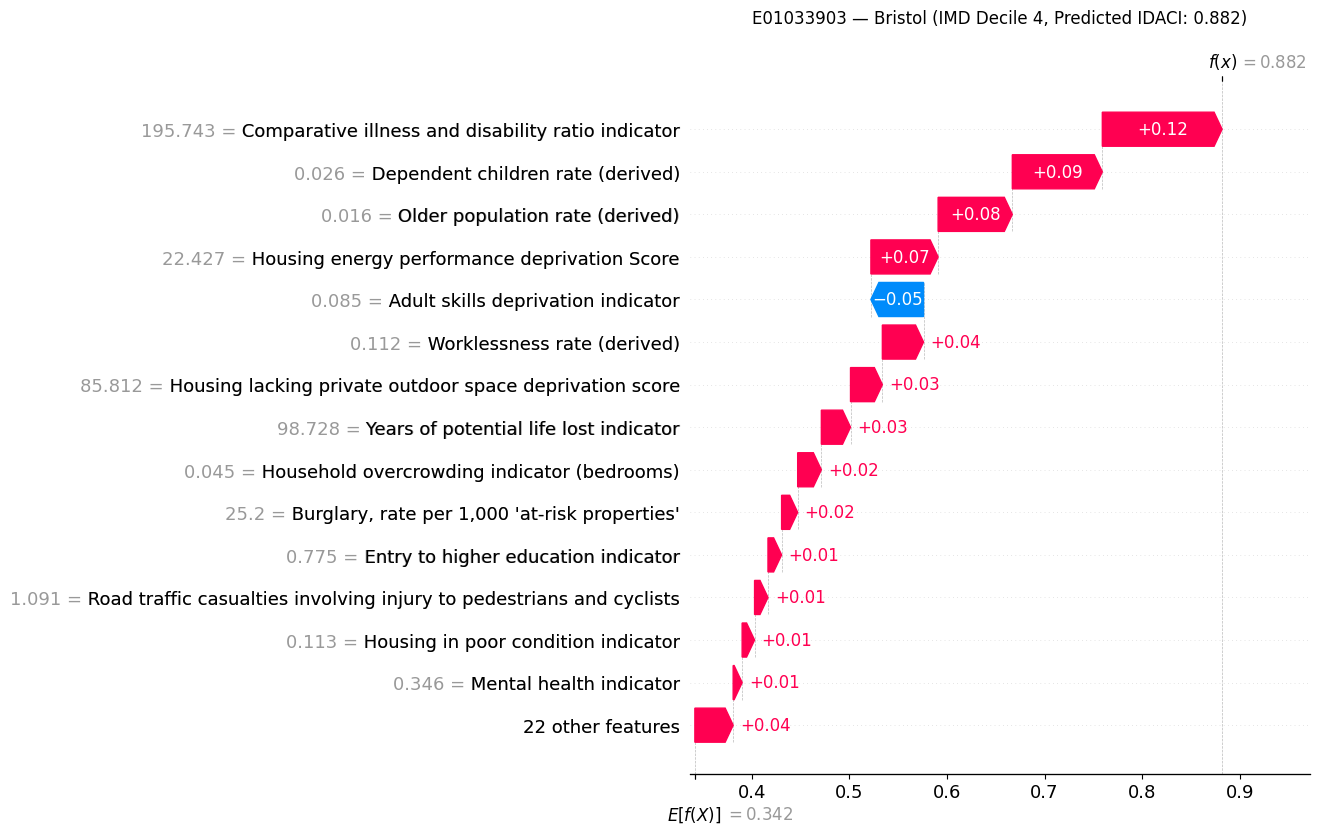

In [24]:
# Bristol: E01033903 (decile 4, predicted 0.882)
target_lsoa_bristol = 'E01033903'
target_pos_bristol = df[df['LSOA code (2021)'] == target_lsoa_bristol].index[0]
target_idx_bristol = df.index.get_loc(target_pos_bristol)

explainer_full = shap.TreeExplainer(xgb_full)
explanation = shap.Explanation(
    values=explainer_full.shap_values(X_imputed.iloc[[target_idx_bristol]])[0],
    base_values=explainer_full.expected_value,
    data=X_imputed.iloc[target_idx_bristol],
    feature_names=X_imputed.columns.tolist()
)
bristol_pred = xgb_full.predict(X_imputed.iloc[[target_idx_bristol]])[0]
plt.title(f'E01033903 — Bristol (IMD Decile 4, Predicted IDACI: {bristol_pred:.3f})', pad=20)
shap.plots.waterfall(explanation, max_display=15)

**Bristol (E01033903)**

Sitting in IMD decile 4, this Bristol neighbourhood is predicted a child poverty score of **0.882**, more than double the national average. Risk is associated primarily with **illness and disability** (+0.12), **dependent children rate** (+0.09), **older population rate** (+0.08), and **poor housing energy performance** (+0.07), with **adult skills deprivation** the only factor pulling the prediction down (-0.05). The co-presence of both high older population and high dependent children rates is consistent with a densely occupied, age-mixed neighbourhood, which links to the housing stressors: poor energy performance and lack of private outdoor space are correlated with the conditions of overcrowded, under-maintained housing stock. This appears to be a health and housing-led risk profile rather than a labour market one.


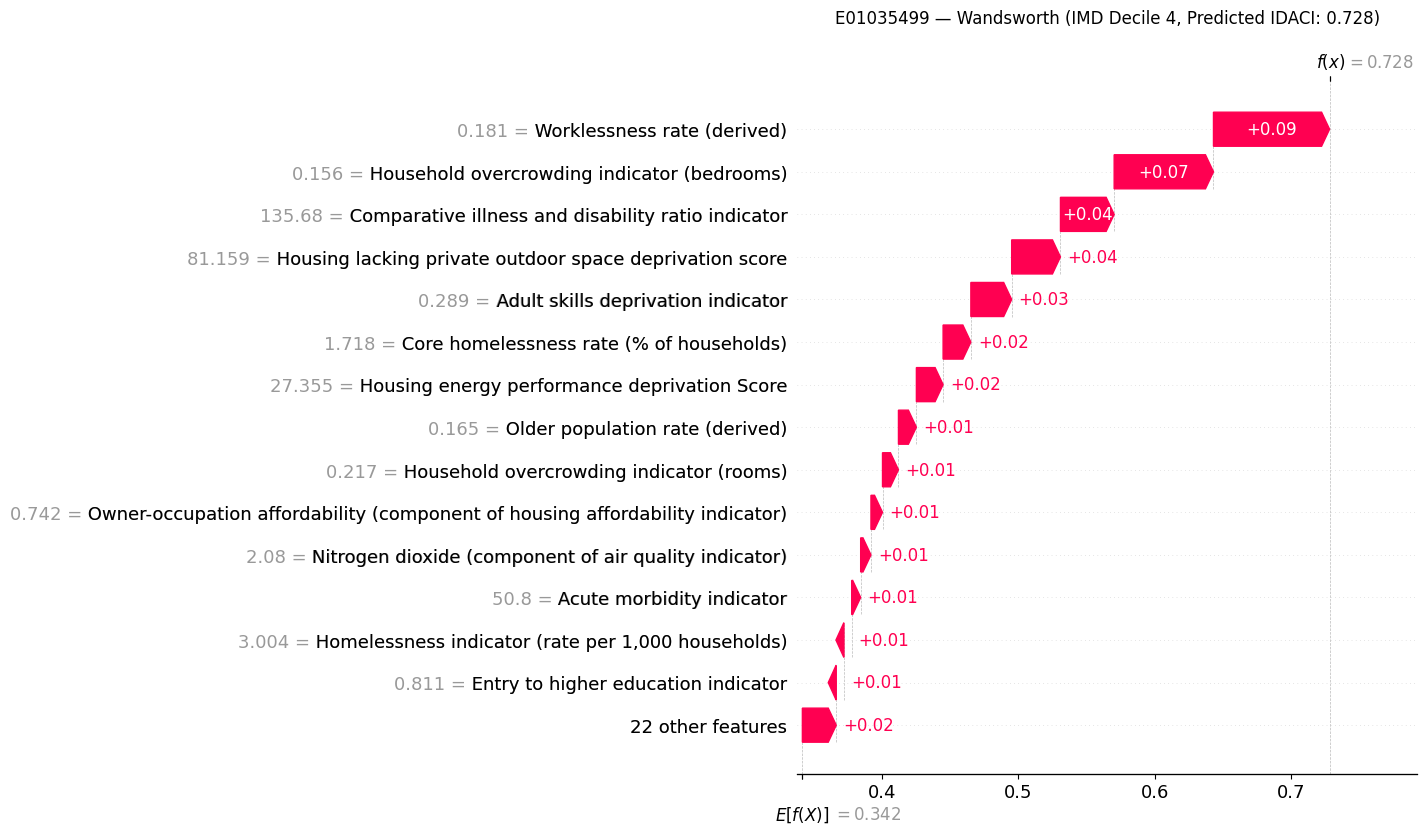

In [25]:
target_lsoa_wandsworth = 'E01035499'
target_pos_wandsworth = df[df['LSOA code (2021)'] == target_lsoa_wandsworth].index[0]
target_idx_wandsworth = df.index.get_loc(target_pos_wandsworth)

explanation = shap.Explanation(
    values=explainer_full.shap_values(X_imputed.iloc[[target_idx_wandsworth]])[0],
    base_values=explainer_full.expected_value,
    data=X_imputed.iloc[target_idx_wandsworth],
    feature_names=X_imputed.columns.tolist()
)
wandsworth_pred = xgb_full.predict(X_imputed.iloc[[target_idx_wandsworth]])[0]
plt.title(f'E01035499 — Wandsworth (IMD Decile 4, Predicted IDACI: {wandsworth_pred:.3f})', pad=20)
shap.plots.waterfall(explanation, max_display=15)

**Wandsworth (E01035499)**

Sitting in IMD decile 4, this Wandsworth neighbourhood is predicted a child poverty score of **0.728**, more than double the national average. Risk is correlated with **worklessness** (+0.09) and **bedroom overcrowding** (+0.07), reflecting household-level labour market and space pressure. **Illness and disability** (+0.04), **housing lacking private outdoor space** (+0.04), and **adult skills deprivation** (+0.03) add further pressure, alongside **core homelessness** (+0.02) and **poor housing energy performance** (+0.02). Every factor pushes the prediction upward with nothing pulling it back. The risk here appears to build from multiple moderate labour market and housing stressors rather than a single dominant driver.


## 5.  Question IV: Worsening Trends & Feature Alignment
While Questions I–III provide a cross-sectional snapshot of child poverty risk across England: identifying its **current structural correlates (QI)**, **highest predicted** geographic **hotspots (QII)**, and **predicted hidden pockets** overlooked by official rankings **(QIII)**, **QIV** introduces a temporal dimension absent from the preceding analysis. Rather than asking **where child poverty risk is highest at a point in time**, it asks **where conditions are actively worsening**, and whether the drivers the model identified in QI can explain that deterioration on the ground.

To bridge the static model predictions with real-world trend analysis, this section is executed in two parts:

**Part 1: Trend Extraction & Indicative Projections (5.1):** Quantifying how child poverty has changed over time using the Children in Low-Income Families (CiLIF) dataset (2021/22 to 2024/25) and isolating "Emerging Risk" hotspots.

**Part 2: Feature Alignment Check (5.2):** Examining whether the factors most associated with child poverty risk in the model are also correlated with observed deterioration in administrative time-series records (Universal Credit, PIP, Housing Benefit, and crime statistics).

### 5.1 Temporal Risk Mapping & Indicative Projections (2021–2025 Trends)

#### 5.1.1 Flagging Deterioration

CiLIF data is available for four financial years (2021/22 to 2024/25), providing a short but meaningful window to assess whether child poverty is worsening, improving, or stable at LSOA level. Each LSOA is classified by the direction of change in its low-income child count across these four years. This classification serves as the basis for identifying deteriorating neighbourhoods before any projection is attempted.

In [ ]:

# Calculate the percentage of LSOAs with worsening trends in child poverty risk according to CiLIF data
cilif_lsoa['Trend'] = cilif_lsoa['Slope'].apply(
    lambda s: 'worsening' if s > 0 else ('improving' if s < 0 else 'stable')
)

worsening_pct = round((cilif_lsoa['Trend'] == 'worsening').mean() * 100, 1)
worsening_count = (cilif_lsoa['Trend'] == 'worsening').sum()
print(f"Worsening: {worsening_pct}%, n={worsening_count:,}")


Worsening: 63.0%, n=21,214


**Child poverty deterioration affects 63% of LSOAs across England between 2021/22 and 2024/25.** With over **21,000 neighbourhoods** on a worsening trajectory, the scale of deterioration warrants examining not just where risk is currently highest, but where it is actively growing, including areas that may not yet appear in deprivation rankings. Early identification of these emerging risk areas is critical, as proactive targeting of interventions and resource allocation may help mitigate worsening deprivation before it becomes more severe and geographically concentrated.

#### 5.1.2 National Trend and Indicative Projection

With **63% of LSOAs on a worsening trajectory**, the scale of deterioration is already clear. What remains unknown is where that trajectory is heading. The chart below aggregates CiLIF counts nationally across all LSOAs and fits a linear trend (numpy.polyfit) to the four available data points, extending it to 2025/26 as an indicative continuation. Given only four data points and a temporary dip in 2023/24, this is an illustrative direction of travel under current conditions, not a forecast.


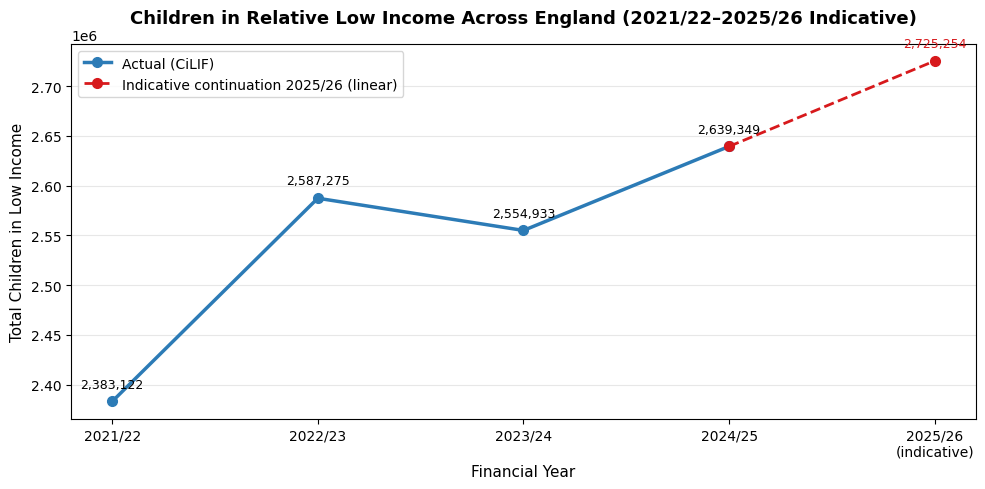

2021/22: 2,383,122
2024/25: 2,639,349
Increase: 256,227
Indicative 2025/26 (linear continuation): 2,725,254


In [27]:
# National totals per year
national = cilif_lsoa[year_cols].sum()
years_actual = [2021, 2022, 2023, 2024]

# Indicative linear continuation as we only have 4 data points, 
# therfore, this is an illustrative trend extension, not a forecast
x_nat = np.array([1, 2, 3, 4])
slope_nat, intercept_nat = np.polyfit(x_nat, national.values, 1)
proj_value = intercept_nat + slope_nat * 5

fig, ax = plt.subplots(figsize=(10, 5))

# Actual trend line
ax.plot(years_actual, national.values, color='#2c7bb6', linewidth=2.5,
        marker='o', markersize=7, label='Actual (CiLIF)')

# Projection (dashed)
ax.plot([2024, 2025], [national.values[-1], proj_value],
        color='#d7191c', linewidth=2, linestyle='--', marker='o',
        markersize=7, label='Indicative continuation 2025/26 (linear)')

# Annotations
for yr, val in zip(years_actual, national.values):
    ax.annotate(f'{int(val):,}', (yr, val), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9)
ax.annotate(f'{int(proj_value):,}', (2025, proj_value),
            textcoords="offset points", xytext=(0, 10),
            ha='center', fontsize=9, color='#d7191c')

ax.set_title('Children in Relative Low Income Across England (2021/22–2025/26 Indicative)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Financial Year', fontsize=11)
ax.set_ylabel('Total Children in Low Income', fontsize=11)
ax.set_xticks([2021, 2022, 2023, 2024, 2025])
ax.set_xticklabels(['2021/22', '2022/23', '2023/24', '2024/25', '2025/26\n(indicative)'])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('q4_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"2021/22: {int(national.iloc[0]):,}")
print(f"2024/25: {int(national.iloc[3]):,}")
print(f"Increase: {int(national.iloc[3] - national.iloc[0]):,}")
print(f"Indicative 2025/26 (linear continuation): {int(proj_value):,}")


Between **2021/22 and 2024/25**, children in relative low income across England rose from **2.38 million to 2.64 million**, an increase of over 256,000 in three years. If this steady trend continues, the number could reach  **2.73 million by 2025/26**.

**Please note:**

* This estimate is based on just four years of fluctuating data.
* It assumes the rate of change will stay constant.
* Actual future numbers may differ based on major policy changes; such as the government's April 2026 removal of the two-child benefit limit, expansions to free school meals, or increases to the National Living Wage.


### 5.2 Do the factors identified by the model align with observed worsening trends?

#### 5.2.1 Identifying Emerging Risk Areas

Across the country, the number of low-income families is steadily rising. However, looking only at this broad national trend hides what is actually happening in individual neighborhoods. To understand the full story, we need to see if child poverty is trapping families in already struggling communities, or if it is spreading into areas that used to be safe. To do this, we compare our xgboost model's risk predictions against the real-world changes happening on the ground over time.

We use a simple grid split into four squares (a quadrant grid) to find "Emerging Risk" areas. These are neighborhoods where our model currently predicts low risk, but real-world child poverty is actually accelerating. To find these hidden spots fairly, we set two thresholds based on the data:

* **The Risk Threshold:** We split all neighborhoods down the middle based on their predicted poverty risk. Anything below the exact middle **(the 50th percentile)** is labeled as "low predicted risk".  
* **The Growth Threshold:** We look at how fast child poverty is rising, adjusted for the size of each neighborhood so big and small areas are compared fairly. We isolate the neighborhoods in the **top 25%**, where poverty is rising faster than three-quarters of the rest of the country.

Neighborhoods that fall into both categories are our **"Emerging Risk"** areas: places that look **safe on paper** but are **actually getting worse** the fastest.


Risk threshold (50th pctile Predicted_IDACI): 0.2979
Growth threshold (75th pctile CiLIF Growth Rate): 18.5185

Checking Model Stability — How neighborhood counts change with different thresholds:
 Risk Target Growth Target   Emerging Risks    Change
-------------------------------------------------------
      p40        p67             2,981        +188
      p40        p75             2,009        -784
      p40        p90               535      -2,258
      p50        p67             4,058      +1,265
      p50        p75             2,793          +0  <-- base
      p50        p90               851      -1,942
      p60        p67             5,366      +2,573
      p60        p75             3,770        +977
      p60        p90             1,238      -1,555


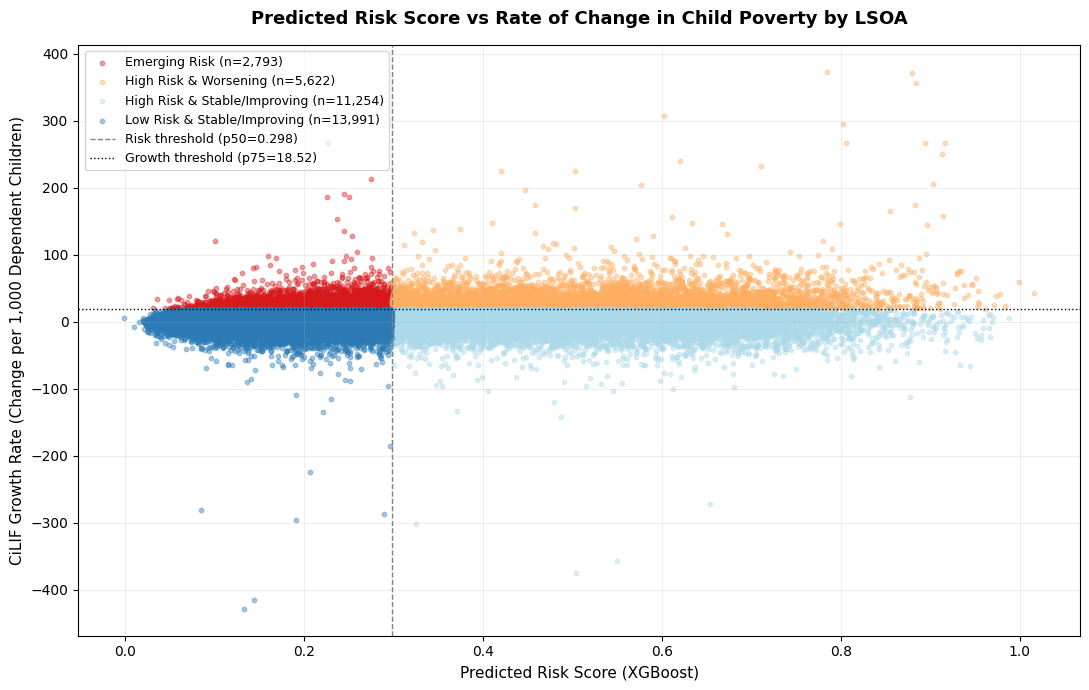

quadrant
Low Risk & Stable/Improving     13991
High Risk & Stable/Improving    11254
High Risk & Worsening            5622
Emerging Risk                    2793
Name: count, dtype: int64


In [28]:
# Risk threshold: 50th percentile of predicted IDACI (national median risk)
risk_threshold = q1_ranking['Predicted_IDACI'].quantile(0.50)
print(f"Risk threshold (50th pctile Predicted_IDACI): {risk_threshold:.4f}")

# Merge risk scores with CiLIF slopes
scatter_df = q1_ranking[['LSOA_code', 'LA_name', 'Predicted_IDACI']].merge(
    cilif_lsoa[['LSOA21CD', 'Slope_per1000']],
    left_on='LSOA_code', right_on='LSOA21CD',
    how='inner'
).dropna().rename(columns={'Slope_per1000': 'Growth_Rate'})

# Growth threshold: 75th percentile of CiLIF slope (top quartile of deteriorating LSOAs)
growth_threshold = scatter_df['Growth_Rate'].quantile(0.75)
print(f"Growth threshold (75th pctile CiLIF Growth Rate): {growth_threshold:.4f}")

# Quadrant labels
def get_quadrant(row, r_thresh, s_thresh):
    if row['Predicted_IDACI'] < r_thresh and row['Growth_Rate'] > s_thresh:
        return 'Emerging Risk'
    elif row['Predicted_IDACI'] >= r_thresh and row['Growth_Rate'] > s_thresh:
        return 'High Risk & Worsening'
    elif row['Predicted_IDACI'] >= r_thresh and row['Growth_Rate'] <= s_thresh:
        return 'High Risk & Stable/Improving'
    else:
        return 'Low Risk & Stable/Improving'

scatter_df['quadrant'] = scatter_df.apply(
    lambda row: get_quadrant(row, risk_threshold, growth_threshold), axis=1
)
n_base = (scatter_df['quadrant'] == 'Emerging Risk').sum()

# We do a sensitivity check by looping over alternative threshold combinations
# Risk percentiles: below median, median, above median, testing what counts as 'low current risk'
risk_percentiles  = [0.40, 0.50, 0.60]

# Growth percentiles: top third, top quarter, top decile, testing how strict the deterioration cut-off is
growth_percentiles = [0.67, 0.75, 0.90]

print(f"\nChecking Model Stability — How neighborhood counts change with different thresholds:")
print(f"{'Risk Target':>12} {'Growth Target':>13} {'Emerging Risks':>16} {'Change':>9}")
print("-" * 55)

for rp in risk_percentiles:
    for sp in growth_percentiles:
        r = q1_ranking['Predicted_IDACI'].quantile(rp)
        s = cilif_lsoa['Slope_per1000'].quantile(sp)
        n = (scatter_df.apply(lambda row: get_quadrant(row, r, s), axis=1) == 'Emerging Risk').sum()
        diff = n - n_base
        marker = "  <-- base" if (rp == 0.50 and sp == 0.75) else ""
        print(f"      p{int(rp*100):02d}        p{int(sp*100):02d}          {n:>8,}      {diff:>+6,}{marker}")

# Colours per quadrant
colours = {
    'Emerging Risk': '#d7191c',
    'High Risk & Worsening': '#fdae61',
    'High Risk & Stable/Improving': '#abd9e9',
    'Low Risk & Stable/Improving': '#2c7bb6'
}

quadrant_order = [
    'Emerging Risk',
    'High Risk & Worsening',
    'High Risk & Stable/Improving',
    'Low Risk & Stable/Improving'
]

fig, ax = plt.subplots(figsize=(11, 7))

for quad in quadrant_order:
    group = scatter_df[scatter_df['quadrant'] == quad]
    ax.scatter(group['Predicted_IDACI'], group['Growth_Rate'],
               c=colours[quad], label=f'{quad} (n={len(group):,})',
               alpha=0.4, s=10)

ax.axvline(risk_threshold, color='grey', linestyle='--', linewidth=1,
           label=f'Risk threshold (p50={risk_threshold:.3f})')
ax.axhline(growth_threshold, color='black', linestyle=':', linewidth=1,
           label=f'Growth threshold (p75={growth_threshold:.2f})')

ax.set_title('Predicted Risk Score vs Rate of Change in Child Poverty by LSOA',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Risk Score (XGBoost)', fontsize=11)
ax.set_ylabel('CiLIF Growth Rate (Change per 1,000 Dependent Children)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('q4_scatter_risk_vs_slope.png', dpi=150, bbox_inches='tight')
plt.show()

print(scatter_df['quadrant'].value_counts())

In [29]:
# Emerging risk summary stats
emerging = scatter_df[scatter_df['quadrant'] == 'Emerging Risk']
mean_growth = emerging['Growth_Rate'].mean()

# Fastest deteriorating emerging risk LSOA
worst_emerging = emerging.loc[emerging['Growth_Rate'].idxmax()]
worst_cilif = cilif_lsoa[cilif_lsoa['LSOA21CD'] == worst_emerging['LSOA_code']][year_cols + ['Slope_per1000']]

# Rewritten print statements to stay non-technical and professional
print(f"Number of 'Emerging Risk' Neighborhoods: {len(emerging):,}")
print(f"Average annual growth rate in child poverty across these areas: {mean_growth:.1f}")
print(f"\n--- Focus Case: The Fastest Deteriorating 'Emerging Risk' Neighborhood ---")
print(worst_emerging[['LSOA_code', 'LA_name', 'Predicted_IDACI', 'Growth_Rate']].to_frame().T.to_string(index=False))
print(f"\nHistorical Child Poverty Counts (Year-by-Year):")
print(worst_cilif.to_string(index=False))

Number of 'Emerging Risk' Neighborhoods: 2,793
Average annual growth rate in child poverty across these areas: 30.0

--- Focus Case: The Fastest Deteriorating 'Emerging Risk' Neighborhood ---
LSOA_code        LA_name Predicted_IDACI Growth_Rate
E01022273 Forest of Dean        0.227121  266.792453

Historical Child Poverty Counts (Year-by-Year):
 2021/22  2022/23  2023/24  2024/25  Slope_per1000
    35.0     45.0    167.0    230.0     266.792453


Of the 33,660 neighborhoods tracked nationally, **2,793 areas** are classified as "Emerging Risk." These are places with low predicted risk on paper that are experiencing a sharp spike in child poverty. On average, these areas see an annual increase of **30 additional children in relative low income per 1,000 children.**

Some areas are deteriorating much faster. For example, one specific neighborhood in the **Forest of Dean** saw its actual count of children in relative low income skyrocket from **35 to 230** between 2021/22 and 2024/25.

Notably, the number of lower-risk areas where child poverty is quietly accelerating is larger than the number of already high-risk areas that are actively worsening. This critical finding proves that rising child poverty is no longer confined to traditionally deprived communities. It is spreading into unexpected areas that are completely overlooked by standard government risk rankings.


#### 5.2.2 Geographic Concentration of Emerging Risk
The quadrant scatter plot reveals that emerging risk LSOAs are widespread across England. To determine whether deterioration is clustering in already-deprived authorities or in less deprived areas that fall outside typical targeting thresholds, the proportion of emerging risk LSOAs is calculated per local authority alongside the median IMD decile.

In [34]:
# Count total and emerging risk areas per Local Authority
la_total = scatter_df.groupby('LA_name').size().reset_index(name='total_areas')
la_emerging = scatter_df[scatter_df['quadrant'] == 'Emerging Risk'].groupby('LA_name').size().reset_index(name='emerging_count')

# Merge and calculate %
la_stats = la_total.merge(la_emerging, on='LA_name', how='left').fillna(0)
la_stats['emerging_pct'] = (la_stats['emerging_count'] / la_stats['total_areas'] * 100).round(1)

# Filter out tiny districts with fewer than 5 neighborhoods total to avoid statistical noise
la_filtered = la_stats[la_stats['total_areas'] >= 5]

# Top 20 by %
top20 = la_filtered.sort_values('emerging_pct', ascending=False).head(20).copy()

# Calculate Median IMD Decile per Local Authority and merge into top20
la_imd = results.groupby('LA_name')['IMD_Decile'].median().round(0).astype(int).reset_index()
la_imd.columns = ['LA_name', 'Median_IMD_Decile']
top20 = top20.merge(la_imd, on='LA_name', how='left')

print(top20[['LA_name', 'Median_IMD_Decile', 'emerging_pct']].sort_values('emerging_pct', ascending=False).to_string(index=False))


                 LA_name  Median_IMD_Decile  emerging_pct
                  Melton                  7          26.7
     Vale of White Horse                  9          23.5
                   Fylde                  7          23.5
        Derbyshire Dales                  7          23.3
              Harborough                  8          23.1
            South Ribble                  8          22.9
          North Kesteven                  7          22.7
           Malvern Hills                  6          22.2
       Oadby and Wigston                  8          22.2
                   Blaby                  8          21.7
             Mid Suffolk                  6          21.1
           Ribble Valley                  8          20.5
               Broadland                  7          20.0
           South Norfolk                  7          19.3
                 Rutland                  8          19.2
     Newark and Sherwood                  6          18.9
Herefordshire,

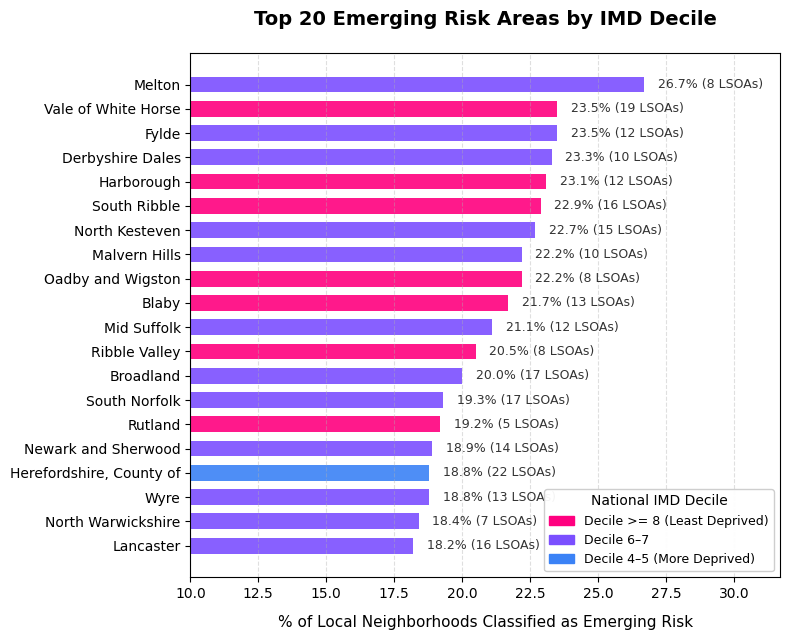

In [ ]:
# Define a function to assign colors based on IMD deciles, with a clear gradient 
# from most deprived (deciles 1-3) to least deprived (deciles 8-10).

def get_color(decile):    
    if decile >= 8:  return '#ff007f'   # Bright Pink for least deprived (deciles 8-10)
    if decile >= 6:  return '#7b4fff'   # Vibrant Purple for mid-range deprivation (deciles 6-7)
    if decile >= 4:  return '#3b82f6'   # Electric Blue for more deprived (deciles 4-5)
    return '#00bfff'    # Deep Sky Blue for most deprived (deciles 1-3)                

top20['Color'] = top20['Median_IMD_Decile'].apply(get_color)

fig, ax = plt.subplots(figsize=(8, 6.5))

# matplotlib plots horizontal bars bottom-to-top by default, so invert the y-axis
ax.invert_yaxis()

# Generate bars using our dynamic color array
bars = ax.barh(top20['LA_name'], top20['emerging_pct'], color=top20['Color'], alpha=0.9, height=0.65)

# Clean labels with percentage and count annotations at the end of each bar
for bar, pct, count in zip(bars, top20['emerging_pct'], top20['emerging_count']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}% ({int(count)} LSOAs)', va='center', ha='left', fontsize=9, color='#333333')

# Formatting labels and grid lines
ax.set_xlabel('% of Local Neighborhoods Classified as Emerging Risk', fontsize=11, labelpad=10)
ax.set_ylabel('')
ax.set_xlim(10, max(top20['emerging_pct']) + 5)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.title('Top 20 Emerging Risk Areas by IMD Decile', fontsize=14, pad=20, weight='bold')

legend_labels = [
    mpatches.Patch(color='#ff007f', label='Decile >= 8 (Least Deprived)'),
    mpatches.Patch(color='#7b4fff', label='Decile 6–7'),
    mpatches.Patch(color='#3b82f6', label='Decile 4–5 (More Deprived)')
]
ax.legend(handles=legend_labels, title='National IMD Decile', loc='lower right', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.savefig('q4_top20_emerging_risk_las.png', dpi=150, bbox_inches='tight')
plt.show()


The results reveal a notable pattern. The local authorities with the highest concentration of **emerging risk LSOAs** are not the urban, historically deprived areas that dominate deprivation headlines. They are **predominantly rural and semi-rural districts: Melton, Vale of White Horse, Fylde, Derbyshire Dales, Harborough**, and **South Ribble** all appear in the top six, with Melton leading at **26.7%** of its neighbourhoods classified as emerging risk.

This contrasts with the findings in Question II, where the highest predicted **child poverty risk** was concentrated in **urban authorities** such as **Hackney, Westminster, Blackpool, and Middlesbrough**, all in **IMD decile 1**. The emerging risk authorities sit at the **opposite end of the deprivation spectrum**, with median IMD deciles ranging from **5 to 9**, placing the majority of their neighbourhoods well outside the thresholds typically used for **deprivation-targeted funding**. This suggests that **relying solely on current deprivation rankings** to allocate resources may leave these areas without support until deterioration becomes more pronounced.

**Note on classification sensitivity:** The emerging risk designation is dependent on **threshold choices**. Counts will change if thresholds are varied; the **sensitivity check** above provides an initial indication of how stable the classifications are to alternative threshold values.

#### 5.2.3 Administrative Feature Overlap & Alignment Check

The five features most associated with child poverty risk in Question I are **worklessness, adult low skills, health barriers/disabilities, household overcrowding**, and **community safety conditions**. To examine whether the model's feature associations are consistent with observed longitudinal patterns, we proxy four of these features against administrative time-series datasets covering 2021–2025. Adult low skills is excluded as no comparable LSOA-level administrative time-series is available for this period.

* **Universal Credit Claimants** → Proxy for Worklessness
* **Personal Independence Payment (PIP) Cases** → Proxy for Illness and Disability
* **Housing Benefit Claimants** → Proxy for Housing Affordability and Overcrowding
* **Police-Recorded Violence and Sexual Offences** → Proxy for Neighbourhood Safety Conditions (stalking and harassment is not recorded as a standalone crime type in the data; violence and sexual offences is used as the closest available proxy)

If the model's feature associations are consistent with real-world patterns, LSOAs experiencing worsening trends in these administrative metrics should show meaningful overlap with LSOAs on deteriorating child poverty trajectories in the CiLIF data. Note that this is an **association-based cross-check, not a causal validation**; the model was trained on cross-sectional deprivation data and SHAP values reflect learned associations within that data rather than causal mechanisms.

For each administrative dataset, a linear slope is fitted across the five available annual values (2021–2025) per LSOA, using the same approach applied to CiLIF in Section 5.1.1 A positive slope indicates worsening conditions; a negative slope indicates improvement. LSOAs with fewer than three valid data points are excluded from slope fitting.

The overlap is then measured as the percentage of CiLIF-worsening LSOAs that also show a positive slope in each administrative metric. A high overlap suggests the model's feature associations are reflected in observed longitudinal patterns on the ground.


In [86]:
# To ensure consistent slope calculation across all datasets, we define a function 
# that merges the yearly dataframes and fits a linear slope for each LSOA. 
# This allows us to compare trends in child poverty (CiLIF), Universal Credit claims, 
# PIP claims, HB claims, and police-recorded violence across the same geographic units.

def fit_slope(yearly_dict, value_col, lsoa_col='LSOA21CD'):
    years = sorted(yearly_dict.keys())
    x = np.arange(1, len(years) + 1)
    
    # Merge yearly dataframes on LSOA code
    merged = yearly_dict[years[0]][[lsoa_col, value_col]].rename(columns={value_col: years[0]})
    for yr in years[1:]:
        merged = merged.merge(yearly_dict[yr][[lsoa_col, value_col]].rename(columns={value_col: yr}),
                              on=lsoa_col, how='outer')
    
    # Fit linear slope for each LSOA, handling missing values by only using valid years
    def slope(row):
        y = row[years].values.astype(float)
        valid = ~np.isnan(y)
        if valid.sum() < 3:
            return np.nan
        return np.polyfit(x[valid], y[valid], 1)[0]
    
    merged['slope'] = merged.apply(slope, axis=1)
    return merged[[lsoa_col, 'slope']]

uc_slopes = fit_slope(uc_yearly, 'uc_mean')
pip_slopes = fit_slope(pip_yearly, 'pip_mean')
hb_slopes = fit_slope(hb_yearly, 'hb_mean')
police_slopes = fit_slope(police_yearly, 'violence_count', lsoa_col='LSOA code')

# Merge all slopes into a single dataframe for correlation analysis
slopes_df = cilif_lsoa[['LSOA21CD', 'Slope_per1000']].rename(columns={'Slope_per1000': 'cilif_slope'})
slopes_df = slopes_df.merge(uc_slopes.rename(columns={'slope': 'uc_slope'}), on='LSOA21CD', how='left')
slopes_df = slopes_df.merge(pip_slopes.rename(columns={'slope': 'pip_slope'}), on='LSOA21CD', how='left')
slopes_df = slopes_df.merge(hb_slopes.rename(columns={'slope': 'hb_slope'}), on='LSOA21CD', how='left')
slopes_df = slopes_df.merge(police_slopes.rename(columns={'LSOA code': 'LSOA21CD', 'slope': 'police_slope'}), on='LSOA21CD', how='left')

# Calculate correlations between CiLIF slope and other indicators
correlations = {
    'Universal Credit': slopes_df[['cilif_slope', 'uc_slope']].dropna().corr().iloc[0, 1],
    'PIP Claims': slopes_df[['cilif_slope', 'pip_slope']].dropna().corr().iloc[0, 1],
    'HB Claims': slopes_df[['cilif_slope', 'hb_slope']].dropna().corr().iloc[0, 1],
    'Police-recorded Violence': slopes_df[['cilif_slope', 'police_slope']].dropna().corr().iloc[0, 1]
}

print(slopes_df.shape)

print("\nCorrelations with CiLIF slope:")
for k, v in correlations.items():
    print(f"  {k}: {v:.4f}")
    

(33660, 6)

Correlations with CiLIF slope:
  Universal Credit: 0.2074
  PIP Claims: 0.1472
  HB Claims: -0.0194
  Police-recorded Violence: 0.0306


UC and PIP show weak positive correlations with the CiLIF slope (0.21 and 0.15 respectively), suggesting that areas where worklessness and disability-related claims are rising tend to also see worsening child poverty trajectories. Housing Benefit and police-recorded violence show near-zero correlations (-0.02 and 0.03), indicating no meaningful linear relationship with CiLIF deterioration at LSOA level.

Correlation coefficients alone, however, summarise the relationship as a single number and can obscure non-linearity, outliers, or threshold effects. The scatter plots below examine the slope relationships directly, showing how each administrative metric tracks against CiLIF deterioration across all LSOAs.

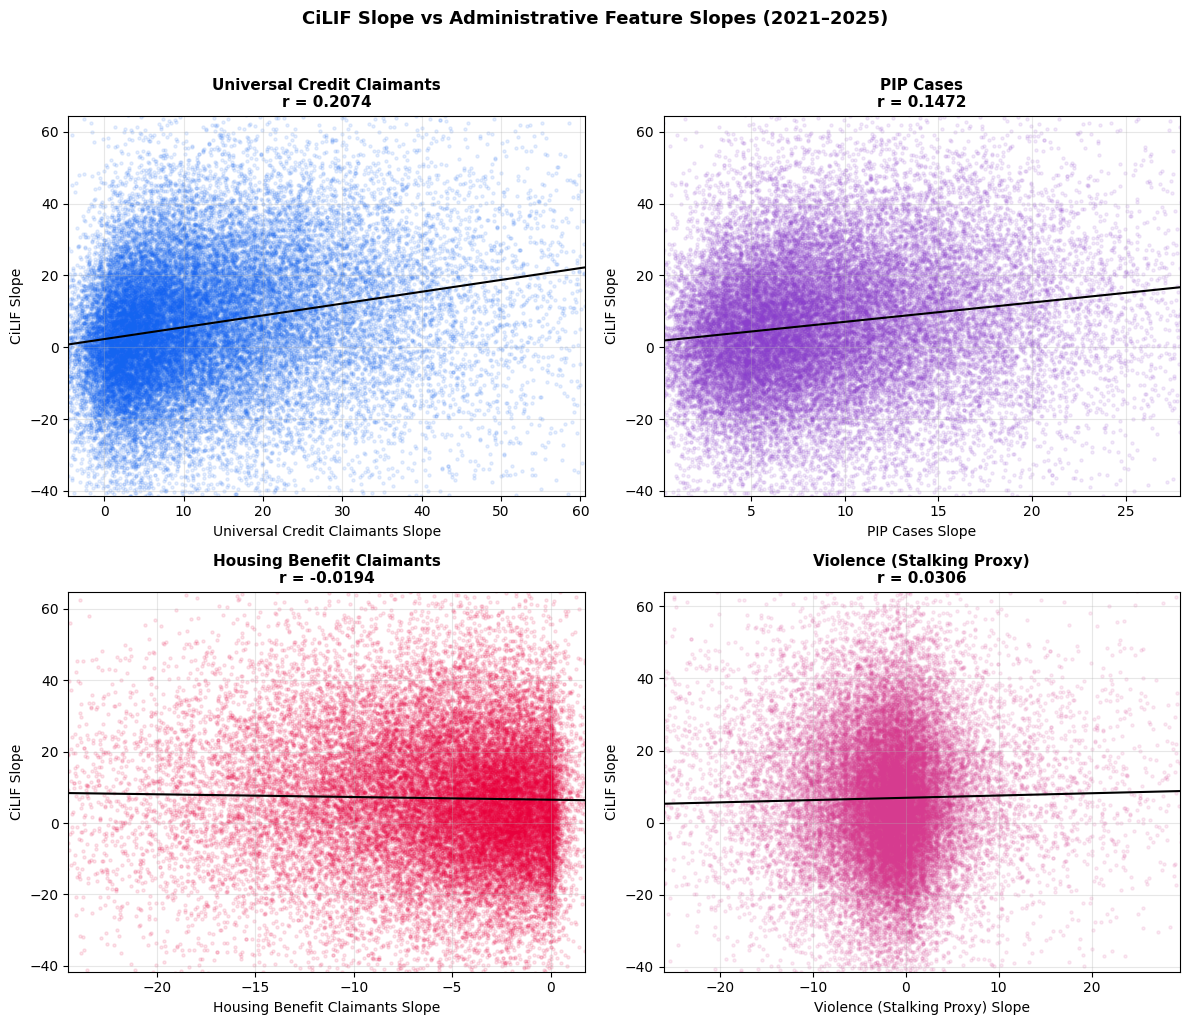

In [95]:
# Visualize correlations with scatter plots and trend lines
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = [
    ('uc_slope', 'Universal Credit Claimants', '#1464f0'),
    ('pip_slope', 'PIP Cases', '#8b3fcc'),
    ('hb_slope', 'Housing Benefit Claimants', '#e8003d'),
    ('police_slope', 'Violence (Stalking Proxy)', '#d63b8f')
]

for ax, (col, label, color) in zip(axes.flatten(), metrics):
    subset = slopes_df[['cilif_slope', col]].dropna()
    r = subset.corr().iloc[0, 1]
    
    ax.scatter(subset[col], subset['cilif_slope'], alpha=0.1, s=5, color=color)
    
    # Trend line
    m, b = np.polyfit(subset[col], subset['cilif_slope'], 1)
    x_line = np.linspace(subset[col].min(), subset[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5)
    
    # Clip axes to 1st-99th percentile to improve readability
    ax.set_xlim(subset[col].quantile(0.01), subset[col].quantile(0.99))
    ax.set_ylim(subset['cilif_slope'].quantile(0.01), subset['cilif_slope'].quantile(0.99))

    ax.set_title(f'{label}\nr = {r:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{label} Slope', fontsize=10)
    ax.set_ylabel('CiLIF Slope', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('CiLIF Slope vs Administrative Feature Slopes (2021–2025)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q4_slope_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

The scatter plots confirm the directional consistency observed in the correlation analysis. Areas where Universal Credit claimants are rising tend to also show rising child poverty trajectories (r = 0.21), and the same pattern holds for PIP cases (r = 0.15). Both relationships are in the expected direction, supporting the model's identification of worklessness and health-related barriers as key drivers of child poverty risk.

Housing Benefit and police-recorded violence show no meaningful linear relationship with CiLIF deterioration. For Housing Benefit, this is largely explained by a structural shift in the data: HB claimants have been declining nationally as households migrate to Universal Credit, which absorbs housing costs. The negative x-axis range visible in the plot reflects this systemic decline rather than improving housing affordability. For police-recorded violence, the wide spread of LSOA-level counts introduces considerable noise, limiting the sensitivity of slope-based detection at this geographic scale.

The modest correlation strengths across all four metrics are consistent with what would be expected from this type of alignment check. The model was trained on cross-sectional deprivation levels, where the cumulative stock of disadvantage across multiple domains simultaneously predicts child poverty risk. A time-series alignment check, by contrast, isolates one administrative proxy at a time across only four to five annual data points, a fundamentally different and more demanding test. The fact that UC and PIP show positive directional alignment under these conditions provides meaningful corroborating evidence that the model's feature associations reflect real-world patterns, rather than artefacts of the cross-sectional training data.

#### 5.2.4 Overlap Analysis: CiLIF Deterioration vs Administrative Trends

The scatter plots in 5.2.3 examined the relationship between administrative trends and child poverty deterioration across all LSOAs, revealing weak but directionally consistent correlations for Universal Credit and PIP. Having established that directional consistency at the population level, the overlap analysis zooms in on the 21,214 LSOAs already identified as worsening in CiLIF and measures what proportion of them also show a positive slope in each administrative metric. A high overlap would indicate that the administrative data is picking up the same deterioration signal as CiLIF, providing stronger corroborating evidence that the model's feature associations reflect real-world patterns on the ground.

In [90]:
# Identify CiLIF-worsening LSOAs
cilif_worsening = slopes_df[slopes_df['cilif_slope'] > 0]['LSOA21CD']

# Calculate overlap for each metric
overlap = {}
for col, label in [('uc_slope', 'Universal Credit'), ('pip_slope', 'PIP Cases'),
                   ('hb_slope', 'Housing Benefit'), ('police_slope', 'Violence (Stalking Proxy)')]:
    subset = slopes_df[slopes_df['LSOA21CD'].isin(cilif_worsening)][['LSOA21CD', col]].dropna()
    also_worsening = (subset[col] > 0).sum()
    pct = round(also_worsening / len(subset) * 100, 1)
    overlap[label] = {'count': also_worsening, 'total': len(subset), 'pct': pct}

for label, vals in overlap.items():
    print(f"{label}: {vals['pct']}% ({vals['count']:,} of {vals['total']:,} worsening LSOAs)")

Universal Credit: 94.1% (19,959 of 21,214 worsening LSOAs)
PIP Cases: 99.5% (21,093 of 21,205 worsening LSOAs)
Housing Benefit: 6.2% (1,272 of 20,597 worsening LSOAs)
Violence (Stalking Proxy): 35.7% (7,210 of 20,205 worsening LSOAs)


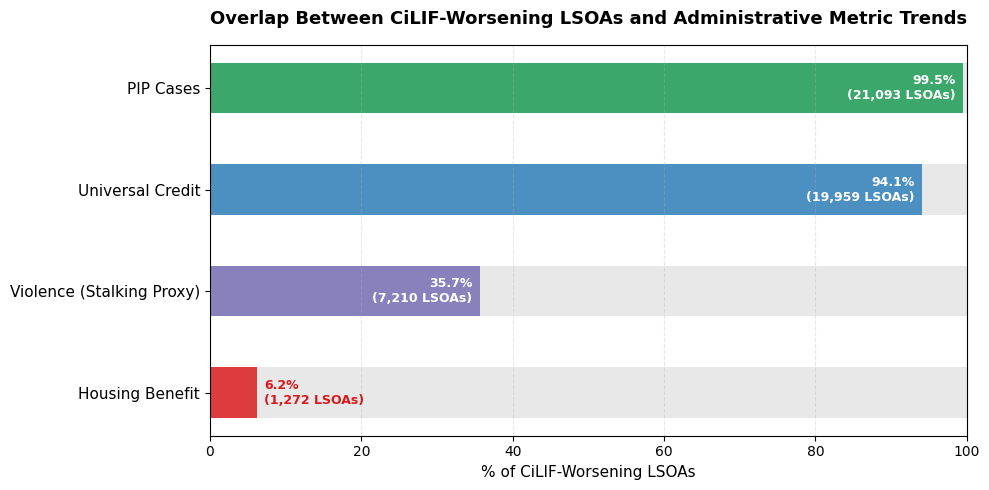

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics_order = sorted(overlap.keys(), key=lambda x: overlap[x]['pct'])
palette = ['#d7191c', '#756bb1', '#2c7bb6', '#1a9850']
colors = {label: palette[i] for i, label in enumerate(metrics_order)}

for i, label in enumerate(metrics_order):
    color = colors[label]
    vals = overlap[label]
    pct_yes = vals['pct']
    pct_no = round(100 - pct_yes, 1)
    
    # Aligned bar
    ax.barh(i, pct_yes, color=colors[label], alpha=0.85, height=0.5)
    ax.barh(i, pct_no, left=pct_yes, color='#d3d3d3', alpha=0.5, height=0.5)
    
    if pct_yes > 15:
        ax.text(pct_yes - 1, i, f'{pct_yes}%\n({vals["count"]:,} LSOAs)', 
            va='center', ha='right', fontsize=9, color='white', fontweight='bold')
    else:
        ax.text(pct_yes + 1, i, f'{pct_yes}%\n({vals["count"]:,} LSOAs)', 
            va='center', ha='left', fontsize=9, color=colors[label], fontweight='bold')

# Formatting
ax.set_yticks(range(len(metrics_order)))
ax.set_yticklabels(metrics_order, fontsize=11)
ax.set_xlabel('% of CiLIF-Worsening LSOAs', fontsize=11)
ax.set_xlim(0, 100)
ax.set_title('Overlap Between CiLIF-Worsening LSOAs and Administrative Metric Trends',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')


plt.tight_layout()
plt.savefig('q4_overlap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

The overlap analysis reveals a striking divergence across the four administrative metrics. Among the **21,214 LSOAs** identified as worsening in CiLIF, **99.5% also show rising PIP cases** and **94.1% show rising Universal Credit claims**. This near-complete overlap confirms that areas experiencing deteriorating child poverty trajectories are overwhelmingly the same areas where **disability-related benefit claims and worklessness** are simultaneously increasing, a strong corroboration of the model's identification of these factors as primary drivers of child poverty risk.

**Violence and sexual offences show moderate overlap at 35.7%**, reflecting the limitations of using a broad crime category as a proxy for the more specific neighbourhood safety conditions captured in the IMD. **Housing Benefit overlap at 6.2%** is explained by the **structural migration of claimants** from Housing Benefit to Universal Credit over this period, which produces a systemic decline in HB caseloads that is unrelated to actual housing affordability conditions on the ground.

Taken together, the alignment check provides **meaningful real-world validation** of the model's cross-sectional findings. The administrative time-series data independently confirms that **worklessness and illness and disability** (the first and third strongest drivers identified by SHAP in Question I) are also the factors most visibly worsening in the same neighbourhoods where child poverty is actively deteriorating.


# 6. Conclusion

Child poverty in England is not random. It clusters in specific neighbourhoods and is associated with a predictable combination of social, economic, health, and housing conditions. This project set out to identify where child poverty risk is highest, which factors are most strongly associated with that risk, and whether areas of emerging concern can be detected before they become widely recognised.

Using data covering all 33,755 LSOAs in England, an XGBoost model was trained to estimate child poverty risk through the Income Deprivation Affecting Children Index (IDACI). Importantly, the model was evaluated using a spatial train-test split, meaning it was tested on local authorities it had never seen before. The model explained a substantial proportion of variation in child poverty risk, suggesting that the selected indicators capture many of the structural conditions associated with deprivation.

The results point to a clear pattern. Worklessness emerged as the strongest predictor of child poverty risk, with an influence substantially greater than any other individual factor. Low educational attainment, health-related barriers, overcrowded housing, and neighbourhood safety conditions also played important roles. While these relationships are not surprising individually, the analysis quantifies their relative importance simultaneously and at neighbourhood level across the whole of England.

The geographic analysis confirmed that many of the highest-risk neighbourhoods are concentrated within England's most deprived local authorities. However, the more significant finding lies beneath the surface. The model identified substantial numbers of neighbourhoods with elevated predicted child poverty risk located within local authorities that appear relatively average when viewed through overall deprivation rankings. These hidden-risk areas suggest that aggregate deprivation measures can mask pockets of disadvantage that exist within otherwise moderate or affluent authorities.

The temporal analysis added an important dimension to this picture. While child poverty increased nationally between 2021/22 and 2024/25, deterioration was not occurring uniformly across England. More than sixty percent of neighbourhoods experienced worsening trends, and nearly 2,800 areas were classified as Emerging Risk locations. Many of these areas are found outside the traditional deprivation hotspots that typically attract policy attention, indicating that future concentrations of disadvantage may already be developing in places not commonly associated with child poverty.

The administrative data provided an independent validation of these findings. In the vast majority of deteriorating neighbourhoods, increases in child poverty occurred alongside rising Universal Credit and Personal Independence Payment claimant counts. The factors most strongly associated with child poverty risk in the model were therefore also visible in real-world administrative records, strengthening confidence that the identified relationships reflect meaningful underlying conditions rather than statistical artefacts.

Taken together, the findings suggest that child poverty is both a current and an emerging challenge. Some of the areas most in need of attention are already visible in official statistics, while others remain hidden beneath average-looking deprivation scores. By combining machine learning, explainable AI, spatial analysis, and trend monitoring, this project demonstrates how data can move beyond describing disadvantage and begin identifying where support may be needed next. **Many future poverty hotspots may already be detectable today. The challenge is recognising them early enough.**


# 7. Limitations and Future Work

Several limitations should be considered when interpreting the findings of this project.

**Cross-sectional modelling.** The XGBoost model was trained using a single snapshot of deprivation indicators from IMD 2025. As a result, the model identifies associations between neighbourhood characteristics and child poverty risk rather than causal relationships. Features identified as important predictors should not be interpreted as direct causes of child poverty, as underlying factors may influence both.

**Limited time horizon for trend analysis.** The CiLIF dataset covers only four financial years (2021/22 to 2024/25). Trend estimates derived from four observations are inherently sensitive to individual years and short-term fluctuations. Consequently, the calculated slopes should be interpreted as indicators of recent direction and momentum rather than long-term trajectories. Any forward projections represent illustrative extensions of current trends rather than formal forecasts.

**Administrative indicators are indirect proxies.** Universal Credit and Personal Independence Payment claimant counts provide useful signals of labour market and health-related pressures, but they measure benefit claims rather than the underlying conditions themselves. Similarly, police-recorded violence and sexual offences were used as a proxy for broader community safety concerns, introducing measurement uncertainty because the available data does not perfectly capture all aspects of neighbourhood safety.

**Housing Benefit trend interpretation.** Housing Benefit claimant counts are influenced by the continuing migration of claimants onto Universal Credit. This administrative change can reduce Housing Benefit caseloads independently of actual housing affordability or housing-related hardship, limiting the usefulness of Housing Benefit trends as a direct indicator of changing need.

**Unobserved factors.** Although the IMD captures multiple dimensions of deprivation, several potentially important influences on child poverty are not available at national LSOA scale. Factors such as household debt, informal childcare availability, food insecurity, social support networks, and digital exclusion are absent from the feature set and may contribute to prediction errors in certain neighbourhoods.

**Spatial dependence.** Despite the use of a spatial train-test split, neighbouring areas often share similar socioeconomic characteristics. Some geographic dependence therefore remains unavoidable, meaning model performance should be interpreted as strong evidence of generalisation rather than a guarantee of equivalent performance in every local context.

**Threshold-based classifications.** The Hidden Risk and Emerging Risk categories are based on analytical thresholds derived from the distribution of predictions and growth rates. Alternative threshold choices would produce different numbers of identified neighbourhoods. These classifications should therefore be viewed as prioritisation tools rather than definitive labels.

### Future Work

Several extensions could strengthen the analysis. As new deprivation data becomes available, a longitudinal modelling framework could replace the current cross-sectional approach, allowing direct analysis of how neighbourhood risk evolves over time. Additional indicators such as Free School Meal eligibility, food insecurity measures, or school-level deprivation metrics could provide further validation and improve predictive performance.

The Emerging Risk framework developed in this project could also be operationalised as an early-warning system, combining machine learning predictions with administrative trend monitoring to identify deteriorating neighbourhoods before they become visible in official deprivation rankings. Such an approach would shift analysis from describing existing disadvantage toward supporting earlier and more proactive intervention.
